# Week 12: AI Tools for Scientific Discovery

**FYS4411 — Reinforcement Learning and Agentic AI**  
University of Oslo, Department of Physics

*Experiment design, domain-specific foundation models, and validation*

This notebook is self-contained and executable. It combines a concise repetition of the lecture, equations, reproducible numerical examples, visual diagnostics, and a short problem set. No API key or external service is required.

In [1]:
import math
import re
from dataclasses import dataclass, field
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(12)
UIO_PURPLE = "#4338B5"
UIO_GREEN = "#2A9D8F"
UIO_RED = "#C84C4C"
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (8.5, 4.8),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

## Learning goals

After completing this notebook, you should be able to

- use LLMs as a controlled scientific workbench rather than an authority;
- translate a research question into a falsifiable design card and executable protocol;
- distinguish general LLMs, domain-specific foundation models (DSFMs), simulators, and validators;
- explain how a DSFM becomes a specialist agent only when embedded in a decision loop;
- implement adaptive quantum experiment design and a DSFM-guided discovery loop;
- diagnose distribution shift, overconfidence, leakage, and self-validation;
- specify domain-appropriate validation for medicine, chemistry, energy, robotics, biology, and quantum science.

## 1. Scientific discovery produces evidence

A scientific result is a claim connected to observations by a reproducible argument. A useful AI-enabled system separates four responsibilities:

| Component | Primary role | Must not be confused with |
|---|---|---|
| general LLM | language, code, decomposition, orchestration | domain-grounded predictor |
| DSFM | scientific representation and prediction | experimental truth |
| simulator or instrument | generate physical or empirical observations | final interpretation |
| validator | tests, independent estimates, replication | proposal generator |

The stable architecture is

$$
\text{question}\rightarrow\text{design}\rightarrow\text{proposal}
\rightarrow\text{independent execution}\rightarrow\text{validation}
\rightarrow\text{revision}.
$$

AI can increase proposal throughput much faster than validation throughput. The acceptance rule therefore matters more, not less.

## 2. The LLM as a scientific workbench

LLMs are especially useful for translating among representations:

$$
\text{question}\leftrightarrow\text{literature map}\leftrightarrow
\text{equations}\leftrightarrow\text{code}\leftrightarrow
\text{tables and figures}\leftrightarrow\text{explanation}.
$$

A scientific prompt should function as a contract:

1. research objective and decision to be made;
2. supplied evidence and authoritative sources;
3. assumptions, units, conventions, and prohibited shortcuts;
4. required output schema and uncertainty;
5. validation tests and acceptance criteria;
6. actions requiring human approval.

Context, model version, code, tool outputs, accepted edits, and verification results form part of the computational experiment.

### Design before code

A compact design card should state:

| Field | Question |
|---|---|
| hypothesis | What observation would support or contradict it? |
| factors | Which variables are controlled or varied? |
| response | What is measured, with what uncertainty? |
| comparator | Which baseline or alternative mechanism is tested? |
| analysis | Which estimator and stopping rule are fixed in advance? |
| validity | Which leakage, bias, shift, and confounding threats matter? |
| artifacts | Which data, code, seeds, environments, and logs are preserved? |

Code should then be generated in small scientifically named components: model, simulator, design policy, estimator, validator, and reporting layer. This makes equation-to-code correspondence inspectable.

## 3. Experiment design as constrained decision-making

Let $d$ be a design, $y$ a possible observation, and $\vartheta$ an uncertain parameter. A Bayesian design may maximize expected information gain

$$
\operatorname{EIG}(d)=
H[p(\vartheta\mid D)]-
\mathbb E_{p(y\mid d,D)}H[p(\vartheta\mid D,y,d)],
$$

possibly subject to time, safety, sample, or energy constraints. This criterion chooses measurements that discriminate among current hypotheses, not merely measurements with large signals.

Sequential design is agentic when each observation changes the next design choice.

## 4. Quantum case study: adaptive Rabi-frequency estimation

For a resonantly driven two-level system with $\hbar=1$,

$$
H=\frac{\Omega}{2}\sigma_x,
\qquad
P_1(t\mid\Omega)=\sin^2\!\left(\frac{\Omega t}{2}\right).
$$

The unknown parameter is $\Omega$. At each round, the agent selects a duration $t$, performs several Bernoulli measurements, updates a posterior over $\Omega$, and chooses the next duration by expected information gain. A small readout-error model prevents probabilities from reaching exactly zero or one.

In [2]:
omega_grid=np.linspace(.45,2.25,650)
time_candidates=np.linspace(.2,7.0,58)
shots_per_round=22
true_omega=1.37

def rabi_probability(omega,t,readout_error=.025):
    ideal=np.sin(np.asarray(omega)*t/2)**2
    return readout_error+(1-2*readout_error)*ideal

def discrete_entropy(probabilities):
    probabilities=np.asarray(probabilities,float)
    return -np.sum(probabilities*np.log(probabilities+1e-300))

def posterior_update(prior,t,successes):
    likelihood=stats.binom.pmf(successes,shots_per_round,rabi_probability(omega_grid,t))
    posterior=prior*likelihood
    return posterior/(posterior.sum()+1e-300)

def expected_information_gain(prior,t):
    success_values=np.arange(shots_per_round+1)
    likelihood=np.array([stats.binom.pmf(k,shots_per_round,rabi_probability(omega_grid,t))
                         for k in success_values])
    predictive=likelihood@prior
    expected_posterior_entropy=0.0
    for k,weight in enumerate(predictive):
        if weight>1e-15:
            posterior=prior*likelihood[k];posterior/=posterior.sum()
            expected_posterior_entropy+=weight*discrete_entropy(posterior)
    return discrete_entropy(prior)-expected_posterior_entropy

uniform_prior=np.ones_like(omega_grid)/len(omega_grid)
initial_eig=np.array([expected_information_gain(uniform_prior,t) for t in time_candidates])

In [3]:
def run_quantum_design(strategy,seed):
    local_rng=np.random.default_rng(seed)
    posterior=uniform_prior.copy()
    records=[];snapshots=[posterior.copy()]
    for round_index in range(12):
        eig=np.array([expected_information_gain(posterior,t) for t in time_candidates])
        if strategy=="adaptive":
            selected_time=float(time_candidates[np.argmax(eig)])
        else:
            selected_time=1.55
        successes=int(local_rng.binomial(shots_per_round,rabi_probability(true_omega,selected_time)))
        posterior=posterior_update(posterior,selected_time,successes)
        mean=float(np.sum(omega_grid*posterior))
        sd=float(np.sqrt(np.sum((omega_grid-mean)**2*posterior)))
        records.append({"round":round_index+1,"time":selected_time,"successes":successes,
                        "posterior_mean":mean,"posterior_sd":sd})
        snapshots.append(posterior.copy())
    return pd.DataFrame(records),snapshots,posterior

adaptive_run,adaptive_snapshots,adaptive_posterior=run_quantum_design("adaptive",120)
fixed_run,fixed_snapshots,fixed_posterior=run_quantum_design("fixed",121)
final_eig=np.array([expected_information_gain(adaptive_posterior,t) for t in time_candidates])
print(pd.DataFrame({
    "strategy":["adaptive EIG","fixed duration"],
    "posterior mean":[adaptive_run.iloc[-1].posterior_mean,fixed_run.iloc[-1].posterior_mean],
    "posterior SD":[adaptive_run.iloc[-1].posterior_sd,fixed_run.iloc[-1].posterior_sd],
    "absolute error":[abs(adaptive_run.iloc[-1].posterior_mean-true_omega),
                      abs(fixed_run.iloc[-1].posterior_mean-true_omega)]
}).to_string(index=False,float_format=lambda z:f"{z:.4f}"))

      strategy  posterior mean  posterior SD  absolute error
  adaptive EIG          1.3723        0.0111          0.0023
fixed duration          1.3767        0.0426          0.0067


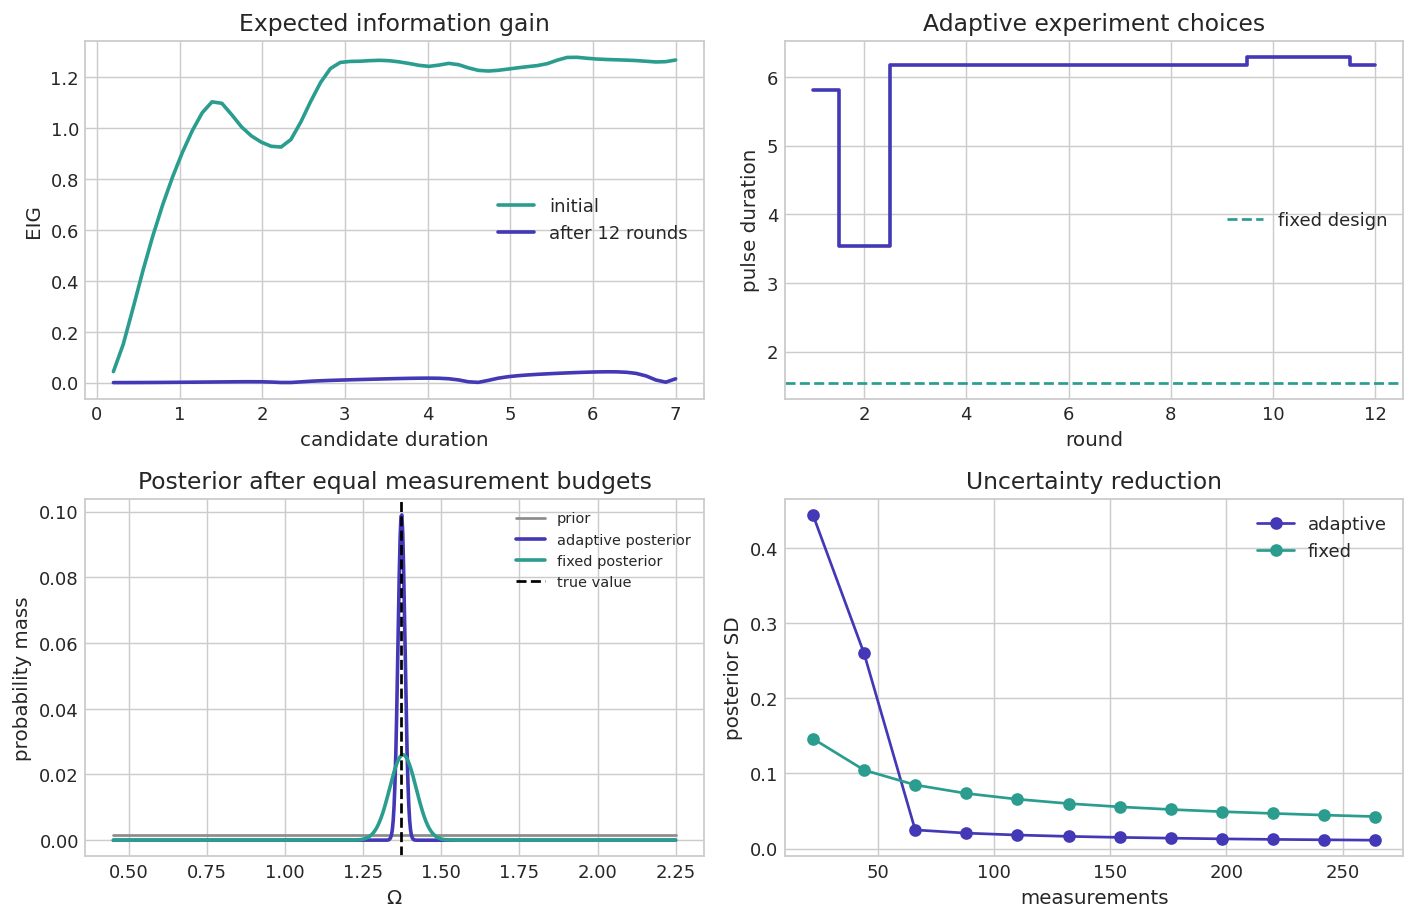

In [4]:
fig,axes=plt.subplots(2,2,figsize=(11,7.2))
axes[0,0].plot(time_candidates,initial_eig,color=UIO_GREEN,lw=2,label="initial")
axes[0,0].plot(time_candidates,final_eig,color=UIO_PURPLE,lw=2,label="after 12 rounds")
axes[0,0].set(title="Expected information gain",xlabel="candidate duration",ylabel="EIG")
axes[0,0].legend()

axes[0,1].step(adaptive_run["round"],adaptive_run["time"],where="mid",color=UIO_PURPLE,lw=2)
axes[0,1].axhline(1.55,color=UIO_GREEN,ls="--",label="fixed design")
axes[0,1].set(title="Adaptive experiment choices",xlabel="round",ylabel="pulse duration")
axes[0,1].legend()

axes[1,0].plot(omega_grid,uniform_prior,color="0.55",label="prior")
axes[1,0].plot(omega_grid,adaptive_posterior,color=UIO_PURPLE,lw=2,label="adaptive posterior")
axes[1,0].plot(omega_grid,fixed_posterior,color=UIO_GREEN,lw=2,label="fixed posterior")
axes[1,0].axvline(true_omega,color="black",ls="--",label="true value")
axes[1,0].set(title="Posterior after equal measurement budgets",xlabel=r"$\Omega$",ylabel="probability mass")
axes[1,0].legend(fontsize=8)

total_shots=shots_per_round*np.arange(1,13)
axes[1,1].plot(total_shots,adaptive_run["posterior_sd"],"o-",color=UIO_PURPLE,label="adaptive")
axes[1,1].plot(total_shots,fixed_run["posterior_sd"],"o-",color=UIO_GREEN,label="fixed")
axes[1,1].set(title="Uncertainty reduction",xlabel="measurements",ylabel="posterior SD")
axes[1,1].legend()
plt.tight_layout();plt.show()

The adaptive policy spends measurements at several durations because a single Rabi probability is periodic in $\Omega$ and can be ambiguous. A credible experiment would include detuning, decoherence, calibration drift, time-dependent control error, and a stopping rule tied to the scientific decision.

The LLM can write the design card and orchestrate tools. The quantum model, likelihood, optimizer, and posterior checks determine the numerical result.

### A factor-of-two error can look plausible

Conventions matter. With $H=\Omega\sigma_x/2$, the correct resonant probability is $\sin^2(\Omega t/2)$. Omitting the factor $1/2$ produces smooth oscillations and valid probabilities but the wrong physical frequency. Analytical invariants are stronger than visual plausibility.

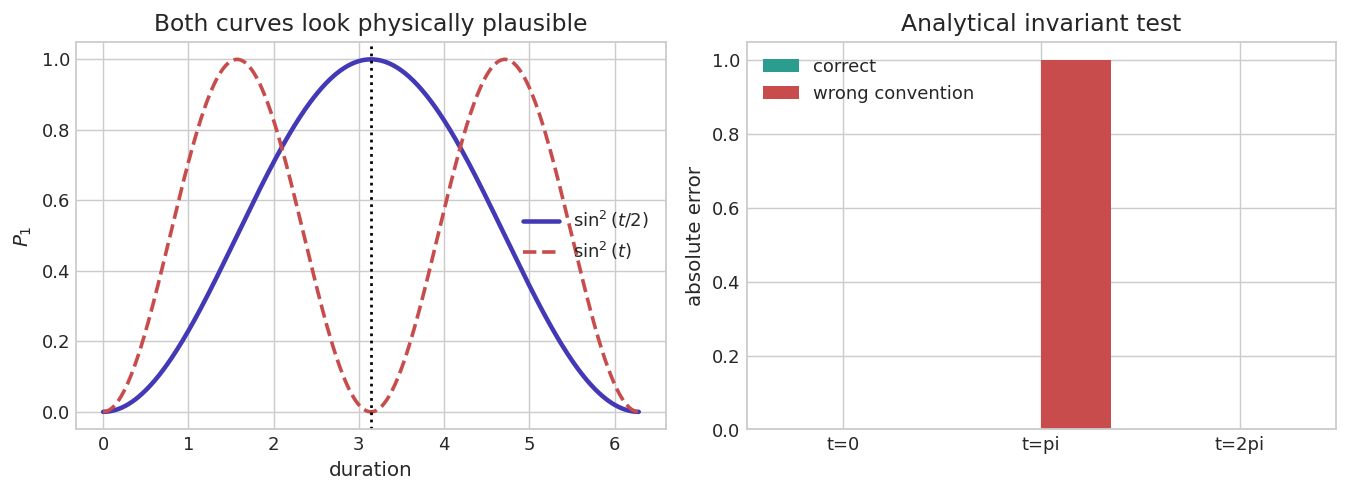

In [5]:
t_test=np.linspace(0,2*np.pi,500)
correct_curve=np.sin(t_test/2)**2
wrong_curve=np.sin(t_test)**2
fig,axes=plt.subplots(1,2,figsize=(10.5,3.9))
axes[0].plot(t_test,correct_curve,color=UIO_PURPLE,lw=2.5,label=r"$\sin^2(t/2)$")
axes[0].plot(t_test,wrong_curve,color=UIO_RED,lw=2,ls="--",label=r"$\sin^2(t)$")
axes[0].axvline(np.pi,color="black",ls=":")
axes[0].set(title="Both curves look physically plausible",xlabel="duration",ylabel=r"$P_1$")
axes[0].legend()
test_times=np.array([0,np.pi,2*np.pi])
expected=np.array([0,1,0])
errors_correct=np.abs(np.sin(test_times/2)**2-expected)
errors_wrong=np.abs(np.sin(test_times)**2-expected)
xloc=np.arange(3);width=.35
axes[1].bar(xloc-width/2,errors_correct,width,color=UIO_GREEN,label="correct")
axes[1].bar(xloc+width/2,errors_wrong,width,color=UIO_RED,label="wrong convention")
axes[1].set_xticks(xloc,["t=0","t=pi","t=2pi"])
axes[1].set(title="Analytical invariant test",ylabel="absolute error")
axes[1].legend()
plt.tight_layout();plt.show()

## 5. Domain-specific foundation models

A DSFM is pretrained on broad data from a scientific domain and reused across tasks. Scientific tokens may be amino acids, atoms and coordinates, periodic lattices, weather fields, satellite patches, spectra, genomes, or trajectories. The architecture should encode relevant geometry, symmetry, conservation, and scale.

A generic self-supervised objective can be written

$$
\min_\theta\mathbb E_{x,m}
\mathcal L\big(f_\theta(m(x)),x\big),
$$

where masking or corruption $m$ forces the model to learn reusable structure.

General LLMs compress language and code. DSFMs compress the objects and dynamics that carry domain-specific scientific information. This is why they often matter more for the predictive core of science.

### Representative DSFMs

| Model family | Domain object | Representative use | Critical validation |
|---|---|---|---|
| AlphaFold | amino-acid sequence and structure | protein structure prediction | confidence, disorder, complexes, experiment |
| Stormer / weather FMs | global atmospheric fields | medium-range forecasting | extremes, regions, lead time, operational baselines |
| Aurora / Earth FMs | atmosphere and Earth-system fields | forecasting and transfer | variable-specific calibration and shift |
| Prithvi-EO | multispectral Earth observation | geospatial transfer tasks | geography, season, sensor shift |
| MatterGen | atom types, coordinates, lattice | conditional crystal generation | stability, novelty, synthesis, measurement |
| biomedical FMs | sequences, cells, assays, images | representation and prioritization | cohort shift and prospective experiment |

AlphaFold, Stormer, or MatterGen is a model, not an agent by itself. It becomes a specialist agent when embedded in a loop that selects tasks, invokes tools, interprets uncertainty, proposes the next action, and records evidence.

## 6. Distribution shift and calibration

A DSFM may perform well on average while failing in rare regimes that matter most. Report errors by region, time, lead, physical regime, demographic group, or measurement platform. Uncertainty is useful only if coverage is tested under shift.

The following synthetic example represents a forecast model that is accurate in ordinary conditions but biased and overconfident in extremes. It is illustrative rather than an empirical claim about a named weather model.

In [6]:
shift_rng=np.random.default_rng(122)
n_shift=1400
regime=np.where(shift_rng.random(n_shift)<.18,"extreme","ordinary")
truth=shift_rng.normal(0,1,n_shift)
truth[regime=="extreme"]=shift_rng.normal(2.4,1.25,np.sum(regime=="extreme"))
prediction=truth+shift_rng.normal(0,.16,n_shift)
extreme_mask=regime=="extreme"
prediction[extreme_mask]+= -.48+shift_rng.normal(0,.34,extreme_mask.sum())
predicted_sd=np.where(extreme_mask,.22,.18)
lower,upper=prediction-1.645*predicted_sd,prediction+1.645*predicted_sd
shift_table=[]
for label in ["ordinary","extreme"]:
    mask=regime==label
    shift_table.append({"regime":label,"n":mask.sum(),
                        "RMSE":np.sqrt(np.mean((prediction[mask]-truth[mask])**2)),
                        "bias":np.mean(prediction[mask]-truth[mask]),
                        "90% interval coverage":np.mean((truth[mask]>=lower[mask])&(truth[mask]<=upper[mask]))})
print(pd.DataFrame(shift_table).to_string(index=False,float_format=lambda z:f"{z:.3f}"))

  regime    n  RMSE   bias  90% interval coverage
ordinary 1147 0.160  0.002                  0.942
 extreme  253 0.566 -0.430                  0.379


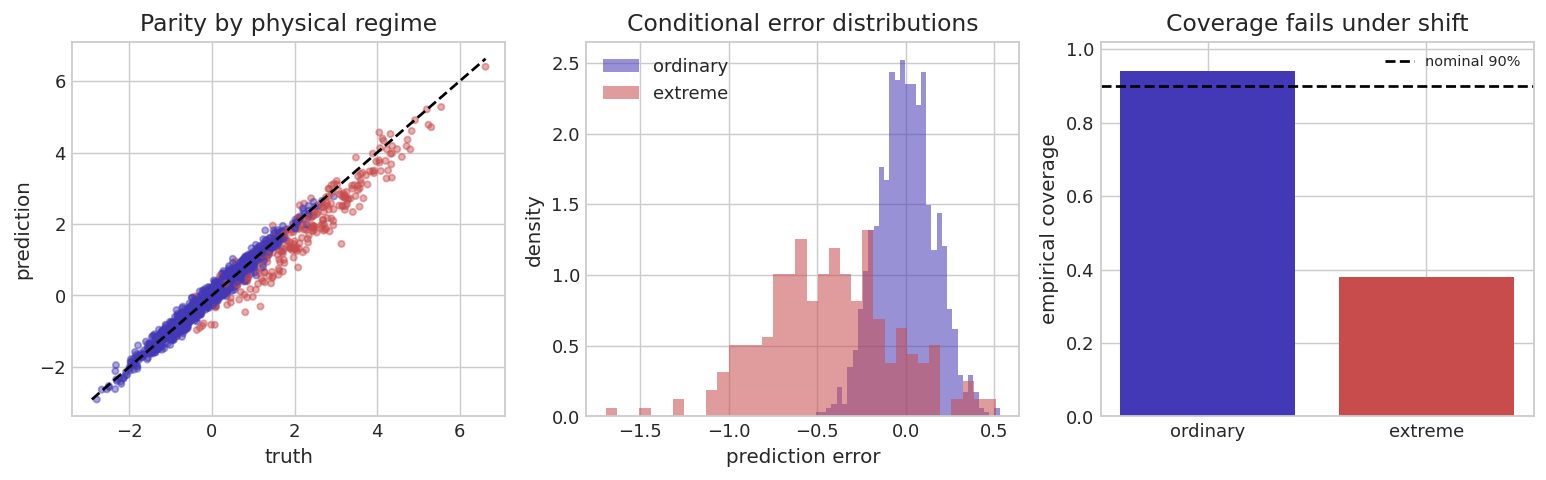

In [7]:
fig,axes=plt.subplots(1,3,figsize=(12,3.8))
colors_shift=np.where(extreme_mask,UIO_RED,UIO_PURPLE)
axes[0].scatter(truth,prediction,c=colors_shift,s=12,alpha=.45)
limits=[min(truth.min(),prediction.min()),max(truth.max(),prediction.max())]
axes[0].plot(limits,limits,color="black",ls="--")
axes[0].set(title="Parity by physical regime",xlabel="truth",ylabel="prediction")
for label,color in [("ordinary",UIO_PURPLE),("extreme",UIO_RED)]:
    mask=regime==label
    axes[1].hist(prediction[mask]-truth[mask],bins=35,density=True,alpha=.55,color=color,label=label)
axes[1].set(title="Conditional error distributions",xlabel="prediction error",ylabel="density")
axes[1].legend()
metrics=pd.DataFrame(shift_table).set_index("regime")
axes[2].bar([0,1],metrics["90% interval coverage"],color=[UIO_PURPLE,UIO_RED])
axes[2].axhline(.9,color="black",ls="--",label="nominal 90%")
axes[2].set_xticks([0,1],["ordinary","extreme"])
axes[2].set(title="Coverage fails under shift",ylabel="empirical coverage",ylim=(0,1.02))
axes[2].legend(fontsize=8)
plt.tight_layout();plt.show()

Aggregate RMSE would conceal the extreme-regime bias and interval undercoverage. This is why weather, medicine, and robotics require field-style validation in regimes where decisions will actually be made.

## 7. A DSFM as a specialist inside a discovery loop

A strong hybrid architecture is

$$
\text{scientist}\leftrightarrow\text{LLM orchestrator}
\leftrightarrow\text{DSFM specialist}
\leftrightarrow\text{simulator or laboratory}
\leftrightarrow\text{validator}.
$$

The DSFM supplies a transferable prior or representation. Exact computation or experiment supplies independent evidence. The controller decides which candidate deserves the next expensive verification.

The toy materials example below starts from a biased domain-model prior, learns corrections from exact evaluations, and selects new candidates using posterior mean plus uncertainty.

In [8]:
material_x=np.linspace(0,1,220)
true_property=(1.25*np.exp(-((material_x-.73)/.095)**2)
               +.76*np.exp(-((material_x-.27)/.16)**2)-.08*material_x)
dsfm_prior=(.82*np.exp(-((material_x-.68)/.18)**2)
            +.62*np.exp(-((material_x-.25)/.20)**2)-.04*material_x)

def rbf_kernel(x1,x2,length=.105,scale=.32):
    return scale**2*np.exp(-.5*((np.asarray(x1)[:,None]-np.asarray(x2)[None,:])/length)**2)

def specialist_posterior(observed_indices,observed_values):
    x_obs=material_x[observed_indices]
    residual=observed_values-dsfm_prior[observed_indices]
    K=rbf_kernel(x_obs,x_obs)+(.025**2+1e-8)*np.eye(len(x_obs))
    cross=rbf_kernel(material_x,x_obs)
    alpha=np.linalg.solve(K,residual)
    mean=dsfm_prior+cross@alpha
    variance=np.diag(rbf_kernel(material_x,material_x))-np.sum(cross*np.linalg.solve(K,cross.T).T,axis=1)
    return mean,np.sqrt(np.maximum(variance,1e-10))

discovery_rng=np.random.default_rng(123)
observed=list(np.linspace(0,219,5,dtype=int))
values=list(true_property[observed]+discovery_rng.normal(0,.02,len(observed)))
best_specialist=[]
for iteration in range(15):
    mean,std=specialist_posterior(np.array(observed),np.array(values))
    acquisition=mean+1.7*std
    acquisition[observed]=-np.inf
    chosen=int(np.argmax(acquisition))
    observed.append(chosen);values.append(float(true_property[chosen]+discovery_rng.normal(0,.02)))
    best_specialist.append(float(np.max(true_property[observed])))
final_mean,final_std=specialist_posterior(np.array(observed),np.array(values))

random_best=np.zeros((80,15))
for seed in range(80):
    rr=np.random.default_rng(500+seed);indices=list(np.linspace(0,219,5,dtype=int))
    for iteration in range(15):
        remaining=np.setdiff1d(np.arange(len(material_x)),indices)
        indices.append(int(rr.choice(remaining)))
        random_best[seed,iteration]=np.max(true_property[indices])

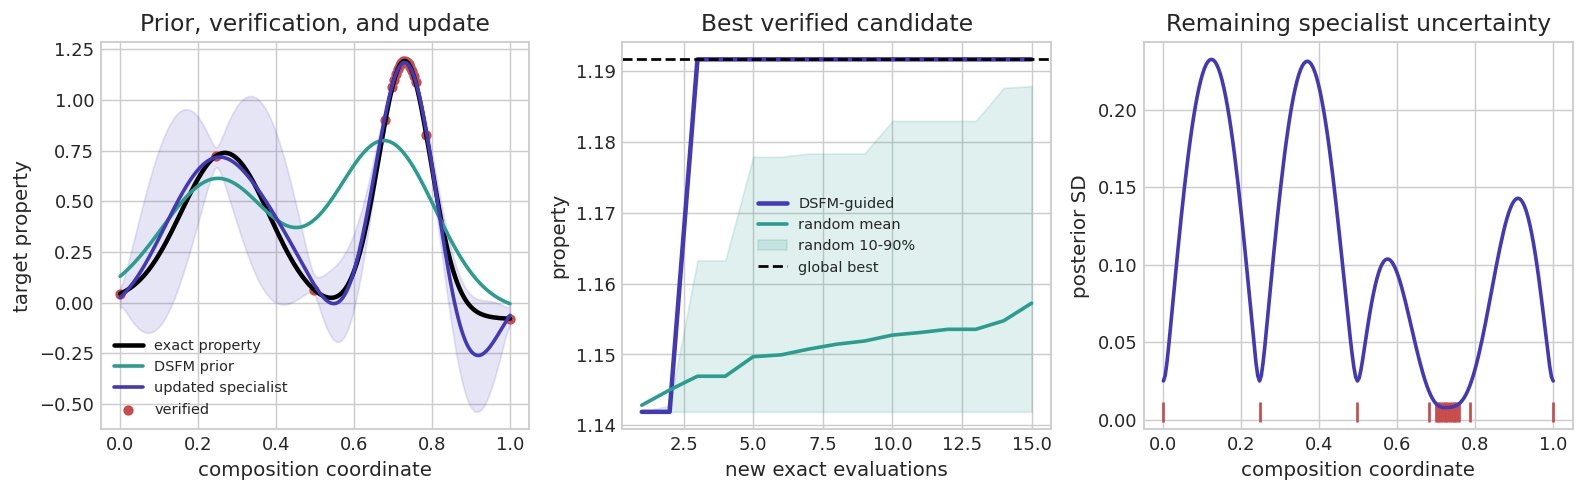

In [9]:
fig,axes=plt.subplots(1,3,figsize=(12.3,3.9))
axes[0].plot(material_x,true_property,color="black",lw=2.5,label="exact property")
axes[0].plot(material_x,dsfm_prior,color=UIO_GREEN,lw=2,label="DSFM prior")
axes[0].plot(material_x,final_mean,color=UIO_PURPLE,lw=2,label="updated specialist")
axes[0].fill_between(material_x,final_mean-1.96*final_std,final_mean+1.96*final_std,
                     color=UIO_PURPLE,alpha=.13)
axes[0].scatter(material_x[observed],true_property[observed],s=22,color=UIO_RED,label="verified")
axes[0].set(title="Prior, verification, and update",xlabel="composition coordinate",ylabel="target property")
axes[0].legend(fontsize=8)

rounds=np.arange(1,16)
axes[1].plot(rounds,best_specialist,color=UIO_PURPLE,lw=2.5,label="DSFM-guided")
axes[1].plot(rounds,random_best.mean(axis=0),color=UIO_GREEN,lw=2,label="random mean")
axes[1].fill_between(rounds,np.quantile(random_best,.1,axis=0),np.quantile(random_best,.9,axis=0),
                     color=UIO_GREEN,alpha=.15,label="random 10-90%")
axes[1].axhline(true_property.max(),color="black",ls="--",label="global best")
axes[1].set(title="Best verified candidate",xlabel="new exact evaluations",ylabel="property")
axes[1].legend(fontsize=8)

axes[2].plot(material_x,final_std,color=UIO_PURPLE,lw=2)
axes[2].scatter(material_x[observed],np.full(len(observed),.005),marker="|",s=120,color=UIO_RED)
axes[2].set(title="Remaining specialist uncertainty",xlabel="composition coordinate",ylabel="posterior SD")
plt.tight_layout();plt.show()

The loop uses a domain prior to allocate expensive verification, but the verifier—not the prior—determines the reported property. Real materials discovery adds structural validity, thermodynamic and kinetic stability, novelty, synthesizability, toxicity, cost, and experimental characterization.

## 8. Applications: stable architecture, different evidence

| Domain | DSFM or specialist model | Agentic decision | Independent evidence |
|---|---|---|---|
| medicine | biomedical sequence, imaging, or patient model | cohort analysis, assay or treatment proposal | external cohort, prospective study, clinician review |
| chemistry | molecular or reaction model | candidate, synthesis, or assay selection | physics calculation, synthesis and measurement |
| energy | weather, load, or materials model | storage, maintenance, experiment allocation | grid constraints, field data, operational trial |
| robotics | vision-language-action or dynamics model | plan and control under feedback | simulator perturbation, hardware test, safety case |
| biology | protein, genome, or cell model | sequence and experiment prioritization | wet-lab assay and replication |
| quantum | circuit, noise, or many-body model | simulation, pulse, calibration, decoder experiment | analytical limit, independent simulator, hardware data |

The LLM coordinates representations and tools. The DSFM carries domain compression. The scientific method determines whether either was useful.

## 9. Validation is part of the method

**Wrong:** accept a generated protocol because it is detailed.  
**Right:** map every step to a hypothesis, control, failure mode, and acceptance criterion.

**Wrong:** report a DSFM's confidence as calibrated uncertainty.  
**Right:** measure conditional coverage on external and shifted data.

**Wrong:** let a proposal model grade its own candidates.  
**Right:** use independent tools, data, evaluators, and where necessary human or laboratory review.

**Wrong:** select the best run and discard failed trajectories.  
**Right:** preserve seeds, environments, negative results, retries, and selection logic.

A reproducible artifact graph links question, data, code, model, environment, run, output, test, figure, and claim through versioned edges.

### Validation ladder

1. dimensional analysis and analytical limits;
2. unit and property-based tests;
3. synthetic recovery with known ground truth;
4. comparison with independent methods and strong baselines;
5. held-out and shifted data with uncertainty calibration;
6. blinded or prospective experiment;
7. independent replication and operational monitoring.

Human approval belongs at consequential transitions: changing the hypothesis, submitting an expensive job, controlling an instrument, using sensitive data, or interpreting evidence as sufficient.

## Problem set

1. Derive the likelihood used for observing $k$ excited-state measurements in the Rabi experiment.
2. Replace expected information gain by posterior variance reduction. Compare selected durations and final uncertainty.
3. Add unknown readout error to the quantum posterior. Which additional designs make $\Omega$ and readout error identifiable?
4. Write three analytical tests that distinguish the two Rabi conventions in the factor-of-two example.
5. For one DSFM, define its scientific tokens, pretraining objective, symmetries, downstream decisions, and validation regimes.
6. Recompute the distribution-shift metrics after calibrating uncertainty on ordinary data only. Explain the result.
7. Change the specialist prior in the materials loop so it is confidently wrong near the optimum. Which acquisition strategies recover?
8. Design a provenance schema linking a generated hypothesis to evidence, code, exact simulation, and final claim.
9. Choose medicine, chemistry, energy, robotics, or biology and specify a validation ladder with a clear stop condition.

**Mini-project.** Build a closed-loop scientific discovery simulation with a general orchestrator, one domain-specific predictive model, and an independent verifier. Compare random, greedy, and uncertainty-aware experiment allocation over at least 30 seeds. Report discovery efficiency, calibration, shifted-regime performance, and every acceptance rule.

## Summary

- LLMs are valuable scientific workbenches for language, code, decomposition, and orchestration.
- Experiment design should begin from falsifiable hypotheses, alternatives, measurements, and acceptance criteria.
- Domain-specific foundation models carry representations of scientific objects and dynamics that general LLMs do not.
- A DSFM becomes a specialist agent only inside a controlled action-feedback loop.
- Adaptive experiment design allocates measurements according to their expected decision or information value.
- Independent validation, distribution-shift tests, provenance, and replication determine whether acceleration becomes knowledge.

**Further reading:** Lecture 12 and its source list; [Agents for Science curriculum](https://agents4science.github.io/Class/curriculum.html); Jumper et al., *Highly accurate protein structure prediction with AlphaFold*; Nguyen et al., *Stormer*; and the attached Gemini guide on structured scientific workflows.